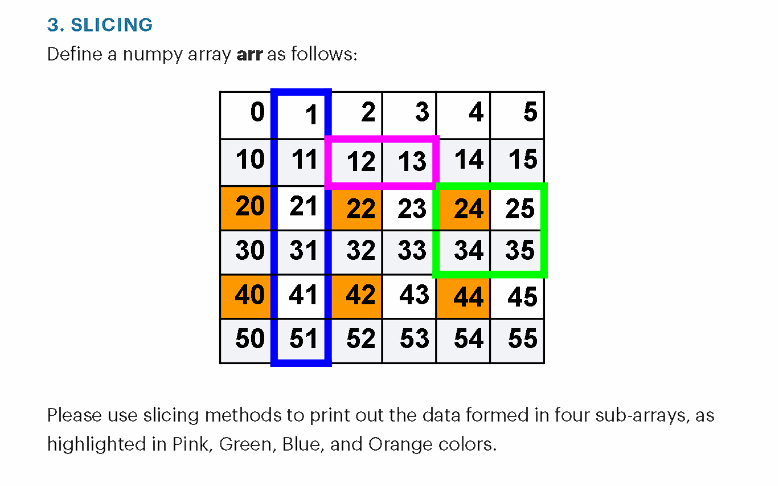

In [361]:
# 1. Read the entire question carefully and identify the input, output, and constraints.
    #input: 6 x 6 array is the input
    #output: 4 sliced sub-arrays
# -------------------------------------------------------------------------------------------------------------------------
# 2. Think about the approach yourself and write down your idea or pseudocode before using AI.
    #
    #


# 3. Try solving it on your own for at least 10–15 minutes.
# 4. If you're stuck, ask Cursor for hints or explanations first—not the complete solution.
# 5. If you do use Cursor's solution, make sure you understand every line and can explain it in your own words.

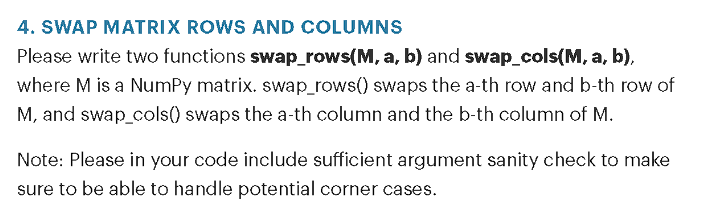

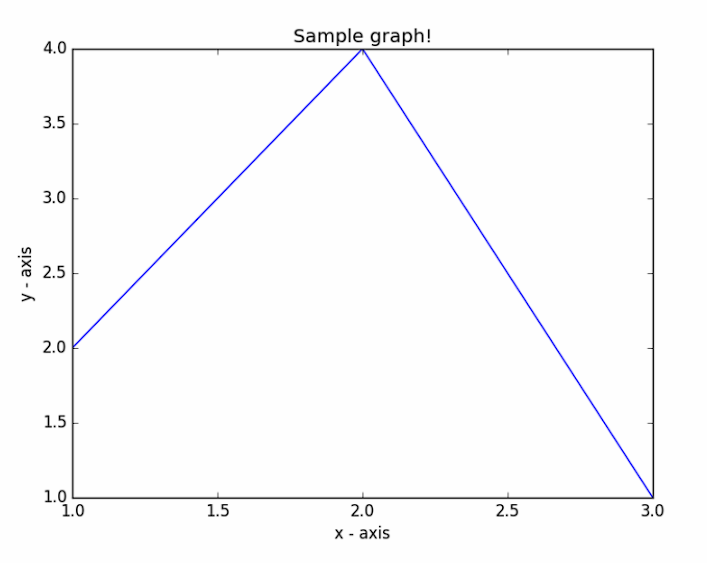

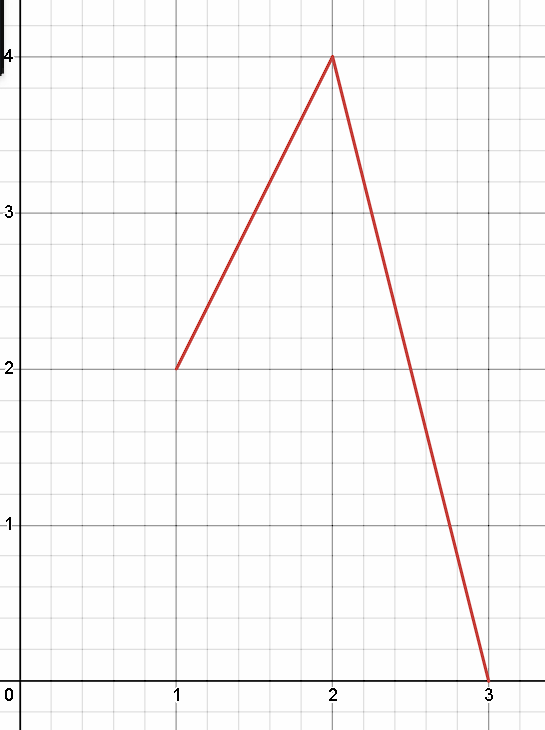

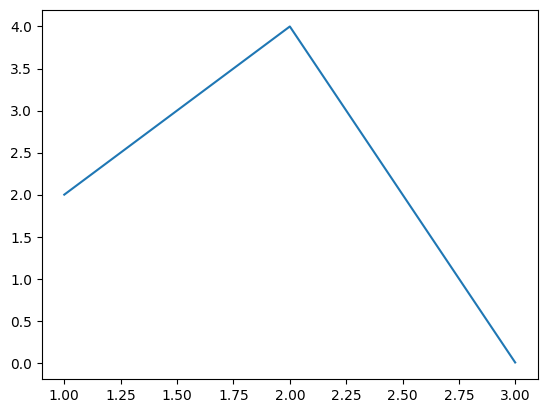

In [362]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.arange(1, 3, 0.001)
# y = []
# for x in xs:
#     if x <= 2:
#         y.append(2 * (x - 1) + 2)
#     else:
#         y.append(-4 * (x - 3))

# --------------------------------------------------------------

y = np.empty_like(xs)
y[xs <= 2] = 2 * (xs[xs <=2 ] - 1) + 2
y[xs > 2] = -4 * (xs[xs > 2] - 3)

plt.plot(xs, y)
plt.show()

Brute-force optimal parameters: a = 2.000, b = -1.000


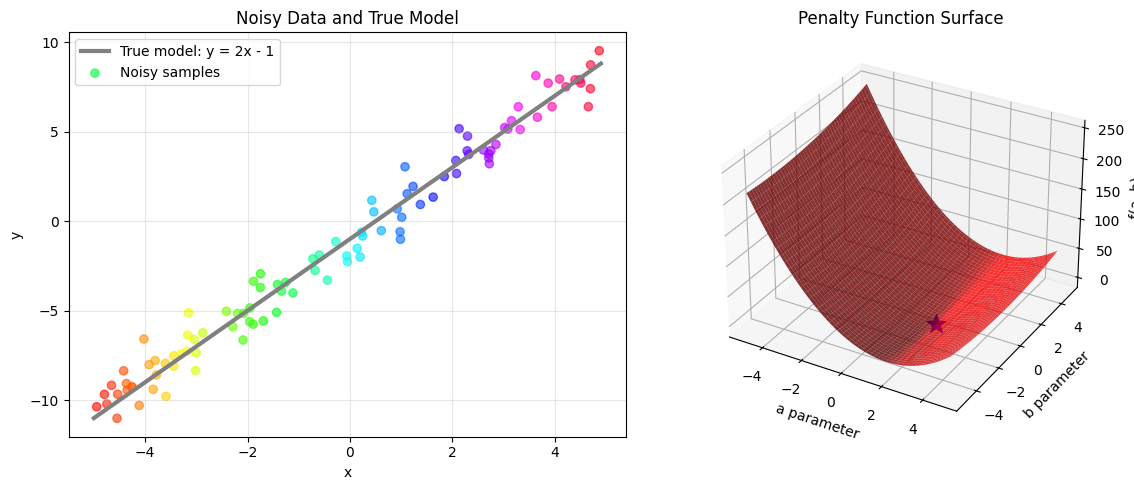

In [363]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

# Set random seed for reproducibility
np.random.seed(42)

# Generate noisy samples from the true model: y = 2x - 1
sample_count = 100
x_sample = 10*np.random.random(sample_count)-5
y_sample = 2*x_sample - 1 + np.random.normal(0, 1.0, sample_count)

# Define the penalty function
def penalty(para_a, para_b):
    squares = (y_sample - para_a*x_sample - para_b)**2
    return 1/2/sample_count*np.sum(squares)

# Create figure with two subplots
fig = plt.figure(figsize=(12, 5))

# Subplot 1: Show the noisy samples and true line
ax1 = fig.add_subplot(1,2,1)
x = np.arange(-5, 5, 0.1)
y = 2*x - 1
ax1.plot(x, y, 'gray', linewidth = 3, label='True model: y = 2x - 1')
ax1.scatter(x_sample, y_sample, c = x_sample, cmap = 'hsv', alpha=0.6, label='Noisy samples')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Noisy Data and True Model')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Show the penalty function surface
ax2 = fig.add_subplot(1,2,2, projection = '3d')

# Create a grid of (a, b) values
a_arr, b_arr = np.meshgrid(np.arange(-5, 5, 0.1), np.arange(-5, 5, 0.1))

# Compute penalty function value for each (a, b) pair
func_value = np.zeros(a_arr.shape)
for ax in range(a_arr.shape[0]):
    for ay in range(a_arr.shape[1]):
        func_value[ax, ay] = penalty(a_arr[ax, ay], b_arr[ax, ay])

# Plot the surface
ax2.plot_surface(a_arr, b_arr, func_value, color = 'red', alpha = 0.8)
ax2.set_xlabel('a parameter')
ax2.set_ylabel('b parameter')
ax2.set_zlabel('f(a, b)')
ax2.set_title('Penalty Function Surface')

# Find and mark the minimum value
optimal_x, optimal_y = np.where(func_value == np.amin(func_value))
print(f"Brute-force optimal parameters: a = {a_arr[optimal_x, optimal_y][0]:.3f}, b = {b_arr[optimal_x, optimal_y][0]:.3f}")
ax2.scatter(a_arr[optimal_x, optimal_y], b_arr[optimal_x, optimal_y], 
    func_value[optimal_x, optimal_y], marker = '*', s=200, c='blue')

plt.tight_layout()
plt.show()

Learning rate 1e-05: Converged to a = -7.999, b = 8.000 in 1 steps
Learning rate 0.0001: Converged to a = 0.477, b = 6.129 in 2000 steps
Learning rate 0.1: Converged to a = 1.954, b = -1.006 in 66 steps
Learning rate 0.02: Converged to a = 1.956, b = -0.966 in 259 steps


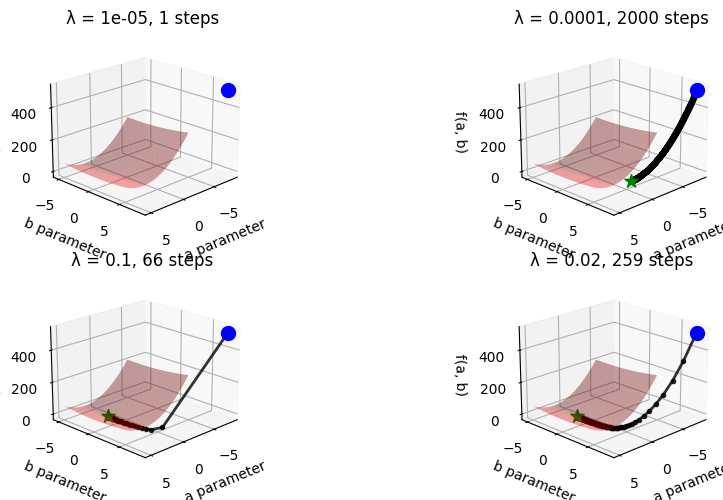

In [364]:
# Gradient descent implementation
def grad(aa):
    """Calculate gradient at point aa = [a, b]"""
    grad_aa = np.zeros(2)
    update_vector = (y_sample - aa[0] * x_sample - aa[1])
    grad_aa[0] = - 1/sample_count * x_sample.dot(update_vector)
    grad_aa[1] = - 1/sample_count * np.sum(update_vector)
    return grad_aa

# Visualization of gradient descent path
fig = plt.figure(figsize=(12, 5))

# Run gradient descent with different learning rates
learning_rates = [0.00001, 0.0001, 0.1, 0.02]
colors = ['blue', 'green', 'orange', 'red']

for idx, learn_rate in enumerate(learning_rates):
    ax = fig.add_subplot(2, 2, idx+1, projection='3d')
    
    # Plot the surface
    ax.plot_surface(a_arr, b_arr, func_value, color='red', alpha=0.4)
    
    # Initialize
    aa = np.array([-8, 8])  # Starting point
    delta = np.inf
    epsilon = 0.001
    step_count = 0
    max_steps = 2000
    
    # Store path for visualization
    path = [aa.copy()]
    
    # Gradient descent loop
    while delta > epsilon and step_count < max_steps:
        aa_next = aa - learn_rate * grad(aa)
        delta = np.linalg.norm(aa - aa_next)
        aa = aa_next
        step_count += 1
        path.append(aa.copy())
    
    # Plot the path
    path = np.array(path)
    z_path = [penalty(p[0], p[1]) for p in path]
    
    # Plot starting and ending points
    ax.scatter(path[0, 0], path[0, 1], z_path[0], c='blue', s=100, marker='o', label='Start')
    ax.scatter(path[-1, 0], path[-1, 1], z_path[-1], c='green', s=100, marker='*', label='End')
    
    # Plot the descent path
    ax.plot(path[:, 0], path[:, 1], z_path, 'ko-', linewidth=2, markersize=3, alpha=0.8)
    
    ax.set_xlabel('a parameter')
    ax.set_ylabel('b parameter')
    ax.set_zlabel('f(a, b)')
    ax.set_title(f'λ = {learn_rate}, {step_count} steps')
    ax.view_init(elev=20, azim=45)
    
    print(f"Learning rate {learn_rate}: Converged to a = {aa[0]:.3f}, b = {aa[1]:.3f} in {step_count} steps")

plt.tight_layout()
plt.show()

In [365]:
# if lr is too high: Divergence
# if lr is too low: then the convergence will take too much steps
# if lr = 0.01: this converges too good

---

## 1. MULTI-LAYER PERCEPTRON FOR LINEARLY NONSEPARABLE DATA

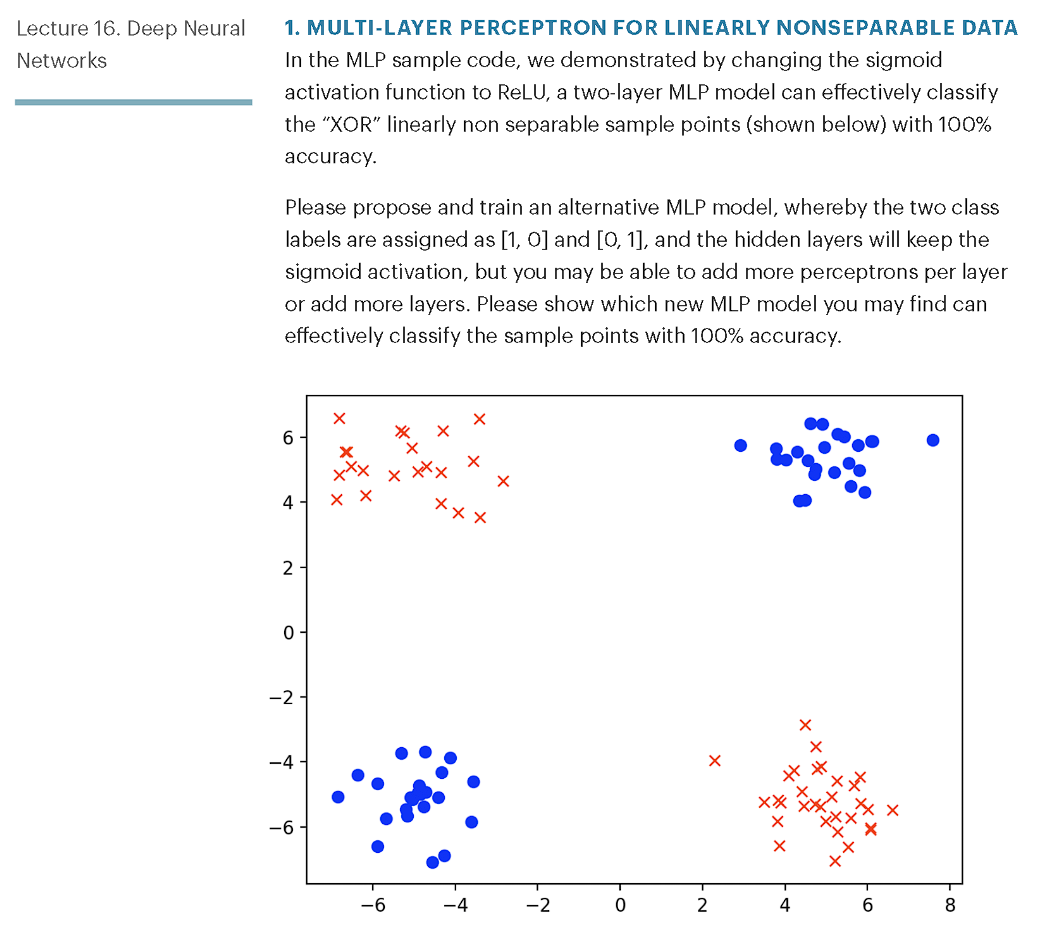

## MLP Architecture for XOR Problem (non-linear data)

In [ ]:
import numpy as np

class LineaLayer:
    def __init__(self, in_dim: int, out_dim: int):
        self.W = np.random.randn(in_dim, out_dim) * np.sqrt(1.0 / in_dim)
        
        self.b = self.b = np.zeros(out_dim)
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b
    
    def backward(self, out_grad):
        self.dW = self.x.T @ out_grad
        self.db = np.sum(out_grad, axis = 0)
        dx = out_grad @ self.W.T
        return dx
    
    def __call__(self, x):
        return self.forward(x)
    
    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]

class ReLU:
    def __init__(self):
        pass

    def forward(self, x):
        self.x = x
        return np.maximum(0, x)
    
    def backward(self, out_grad):
        return out_grad * (self.x > 0)
    
    def __call__(self, x):
        return self.forward(x)
    
    def params(self):
        return []
    
class Sigmoid:
    def __init__(self):
        pass

    def forward(self, x):
        self.out = 1 / (1 + np.exp(-x))
        # self.out = np.where(
        #     x >= 0,
        #     1 / (1 + np.exp(-x)),
        #     np.exp(x) / (1 + np.exp(x))
        # )
        return self.out

    def backward(self, out_grad):
        return out_grad * (self.out * (1 - self.out)) 
    
    def __call__(self, x):
        return self.forward(x)
    
    def params(self):
        return []

class MSELoss:
    def __init__(self):
        pass

    def forward(self, y_true, logits):
        self.N = len(y_true)
        self.y_true = y_true
        self.logits = logits
        return np.mean((y_true - logits) ** 2)

    def backward(self):
        loss_grad = (-2 / self.N) * (self.y_true - self.logits)
        return loss_grad
    
    def __call__(self, y_true, logits):
        return self.forward(y_true, logits)
    
    def params(self):
        return []

class MLPBlock:
    def __init__(self, in_dim: int, out_dim: int):
        self.mlp_block = [LineaLayer(in_dim = in_dim, out_dim = out_dim), ReLU()]
    
    def forward(self, x):
        for layer in self.mlp_block:
            x = layer(x)
        return x
    
    def backward(self, out_grad):
        for layer in self.mlp_block[::-1]:
            out_grad = layer.backward(out_grad)
        return out_grad
    
    def __call__(self, x):
        return self.forward(x)
    
    def params(self):
        self.param = []
        for layer in self.mlp_block:
            self.param.extend(layer.params())
        return self.param
    
class MLP:
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, n_layers: int):
        
        # This is my 1st layer (Input Layer)
        self.layers = [MLPBlock(
            in_dim = in_dim,
            out_dim = hidden_dim
        )]

        # These are my hidden layers (Hidden Layer)
        for _ in range(n_layers - 2):
            self.layers.append(
                MLPBlock(
                in_dim = hidden_dim,
                out_dim = hidden_dim
            ))
        
        # This is my Final Layer (Final Layer)
        self.layers.append(
            LineaLayer(
                in_dim = hidden_dim,
                out_dim = out_dim
            )
        )

        self._get_layer_details()

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def backward(self, out_grad):
        for layer in self.layers[::-1]:
            out_grad = layer.backward(out_grad)
        return out_grad
    
    def __call__(self, x):
        return self.forward(x)
    
    def params(self):
        self.param = []
        for layer in self.layers:
            self.param.extend(layer.params())
        return self.param
    
    def _get_layer_details(self):
        print(f"------------------------- MLP Details -------------------------")
        for layer in self.layers:
            if isinstance(layer, MLPBlock):
                for sub_layer in layer.mlp_block:
                    if not isinstance(sub_layer, ReLU):
                        print(f"{sub_layer.__class__.__name__} | W.shape = {sub_layer.W.shape} | b.shape = {sub_layer.b.shape}")
                    else:
                        print(f"{sub_layer.__class__.__name__} | Activation Function")

            else:
                print(f"{layer.__class__.__name__} | W.shape = {layer.W.shape} | b.shape = {layer.b.shape} [FINAL LAYER]")

                # print(f"{sub_layer.__class__.__name__} | W.shape = {sub_layer.W.shape} | b.shape = {sub_layer.b.shape}")

### Before training on real Dataset, let's overfit on a small batch of 10 data samples

In [612]:
BATCH = 10
x = np.random.rand(BATCH, 2)
y_true = np.random.randint(low = 0, high = 2, size = (BATCH,))
mlp = MLP(in_dim = 2, hidden_dim = 3, out_dim = 1, n_layers = 3)
sigmoid_fn = Sigmoid()
loss_fn = MSELoss()
lr = 0.01

------------------------- MLP Details -------------------------
LineaLayer | W.shape = (2, 3) | b.shape = (3,)
ReLU | Activation Function
LineaLayer | W.shape = (3, 3) | b.shape = (3,)
ReLU | Activation Function
LineaLayer | W.shape = (3, 1) | b.shape = (1,) [FINAL LAYER]


In [613]:
### Before training
print("---------------------- Before Training ----------------------")
print(f"y_true = {y_true}")
print(f"y_preds = {(1 * (sigmoid_fn(mlp(x)) > 0.5)).reshape(-1,)}")

---------------------- Before Training ----------------------
y_true = [1 0 1 1 1 0 0 1 0 1]
y_preds = [0 0 0 0 0 0 0 0 0 0]


In [614]:
for epoch in range(1000):
    # ---------- Forward Pass --------------------------
    logits = mlp(x)
    probs = sigmoid_fn(logits)
    loss = loss_fn(y_true.reshape(-1, 1), probs)

    # ---------- Backward Pass --------------------------
    loss_grad = loss_fn.backward()
    sigmoid_grad = sigmoid_fn.backward(loss_grad)
    mlp.backward(sigmoid_grad)

    # ---------- Gradient Descent ----------------------
    for param, grad in mlp.params():
        param -= lr * grad

    if epoch % 100 == 0:
        print(f"Epoch = [{epoch} / {100}] | Loss = {loss:.4f}")

Epoch = [0 / 100] | Loss = 0.2737
Epoch = [100 / 100] | Loss = 0.2581
Epoch = [200 / 100] | Loss = 0.2502
Epoch = [300 / 100] | Loss = 0.2456
Epoch = [400 / 100] | Loss = 0.2428
Epoch = [500 / 100] | Loss = 0.2406
Epoch = [600 / 100] | Loss = 0.2395
Epoch = [700 / 100] | Loss = 0.2390
Epoch = [800 / 100] | Loss = 0.2386
Epoch = [900 / 100] | Loss = 0.2383


In [615]:
### Before training
print("---------------------- After Training ----------------------")
print(f"y_true = {y_true}")
print(f"y_preds = {(1 * (sigmoid_fn(mlp(x)) > 0.5)).reshape(-1,)}")

---------------------- After Training ----------------------
y_true = [1 0 1 1 1 0 0 1 0 1]
y_preds = [1 1 1 1 1 1 1 1 1 1]


In [616]:
# -------------------------------------------------
# sigmoid backward pass shape analysis:

# BUG: loss_grad.shape was (batch,), so sigmoid_grad = loss_grad * sigmoid_grad --> shapes were = (5,) * (5, 1) = (1, 5) * (5, 1) = (5, 5)
# FIX: reshape loss_grad as (-1, 1)
# -------------------------------------------------
print(f"Sigmoid Input shape = {mlp(x).shape}")
print(f"Sigmoid Output shape = {sigmoid_fn(mlp(x)).shape}")
loss_grad = loss_fn.backward()
sigmoid_grad = sigmoid_fn.backward(loss_grad)
print(f"out_grad.shape for sigmoid = {loss_grad.shape}")
print(f"Sigmoid Grad shape = {sigmoid_grad.shape}")

print(f"\n----------------------------- After FIX -----------------------------")
print(f"Sigmoid Input shape = {mlp(x).shape}")
print(f"Sigmoid Output shape = {sigmoid_fn(mlp(x)).shape}")
loss_grad = loss_fn.backward().reshape(-1, 1)
sigmoid_grad = sigmoid_fn.backward(loss_grad)
print(f"out_grad.shape for sigmoid = {loss_grad.shape}")
print(f"Sigmoid Grad shape = {sigmoid_grad.shape}")

Sigmoid Input shape = (10, 1)
Sigmoid Output shape = (10, 1)
out_grad.shape for sigmoid = (10, 1)
Sigmoid Grad shape = (10, 1)

----------------------------- After FIX -----------------------------
Sigmoid Input shape = (10, 1)
Sigmoid Output shape = (10, 1)
out_grad.shape for sigmoid = (10, 1)
Sigmoid Grad shape = (10, 1)


---

## Let's Train it on XOR Dataset

### Get the Data

In [617]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 100          # samples per cluster
std = 0.7

# Class 0 (blue)
c1 = np.random.randn(N,2)*std + np.array([-5,-5])
c2 = np.random.randn(N,2)*std + np.array([5,5])

# Class 1 (red)
c3 = np.random.randn(N,2)*std + np.array([-5,5])
c4 = np.random.randn(N,2)*std + np.array([5,-5])

X = np.vstack([c1,c2,c3,c4])

y = np.array(
    [0]*N +
    [0]*N +
    [1]*N +
    [1]*N
)
y_onehot = np.zeros((len(y),2))
y_onehot[np.arange(len(y)), y] = 1

# ------------ Train test split ----------------------
perm = np.random.permutation(len(X))

X = X[perm]
y = y_onehot[perm]

split = int(0.8 * len(X))

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

### Visualize the Dataset

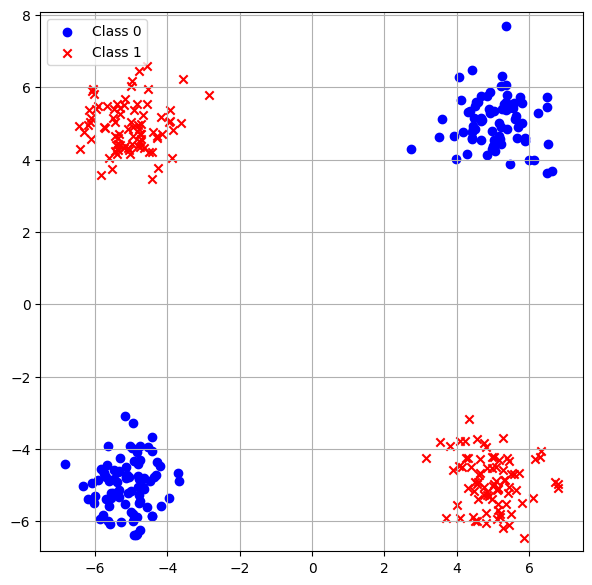

In [618]:
plt.figure(figsize=(7,7))
labels = np.argmax(y_train, axis=1)
plt.scatter(
    X_train[labels==0][:,0],
    X_train[labels==0][:,1],
    color="blue",
    label="Class 0"
)

plt.scatter(
    X_train[labels==1][:,0],
    X_train[labels==1][:,1],
    color="red",
    marker="x",
    label="Class 1"
)

plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

## Train on this dataset

In [619]:
mlp = MLP(in_dim = 2, hidden_dim = 8, out_dim = 2, n_layers = 5)
out_features = 2
sigmoid_fn = Sigmoid()
loss_fn = MSELoss()
lr = 0.1
EPOCHS = 100

------------------------- MLP Details -------------------------
LineaLayer | W.shape = (2, 8) | b.shape = (8,)
ReLU | Activation Function
LineaLayer | W.shape = (8, 8) | b.shape = (8,)
ReLU | Activation Function
LineaLayer | W.shape = (8, 8) | b.shape = (8,)
ReLU | Activation Function
LineaLayer | W.shape = (8, 8) | b.shape = (8,)
ReLU | Activation Function
LineaLayer | W.shape = (8, 2) | b.shape = (2,) [FINAL LAYER]


#### Training Loop

In [ ]:
for epoch in range(EPOCHS):
    # ---------- Forward Pass --------------------------
    logits = mlp(X_train)
    probs = sigmoid_fn(logits)
    loss = loss_fn(y_train.reshape(-1, out_features), probs)

    # ---------- Backward Pass --------------------------
    loss_grad = loss_fn.backward()
    sigmoid_grad = sigmoid_fn.backward(loss_grad)
    mlp.backward(sigmoid_grad)

    # ---------- Gradient Descent (SGD) or you could also use Adam Optimizer too----------------------
    for param, grad in mlp.params():
        param -= lr * grad

    if epoch % 10 == 0:
        print(f"Epoch = [{epoch} / {EPOCHS}] | Loss = {loss:.4f}")

Epoch = [0 / 100] | Loss = 0.2666
Epoch = [10 / 100] | Loss = 0.1627
Epoch = [20 / 100] | Loss = 0.1058
Epoch = [30 / 100] | Loss = 0.0228
Epoch = [40 / 100] | Loss = 0.0075
Epoch = [50 / 100] | Loss = 0.0037
Epoch = [60 / 100] | Loss = 0.0022
Epoch = [70 / 100] | Loss = 0.0016
Epoch = [80 / 100] | Loss = 0.0012
Epoch = [90 / 100] | Loss = 0.0009


In [621]:
logits = mlp(X_test)
probs = sigmoid_fn(logits)
preds = np.argmax(probs, axis=1)
true = np.argmax(y_test, axis=1)

accuracy = np.mean(preds == true)

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : 100.00%


### Plot the Predictions

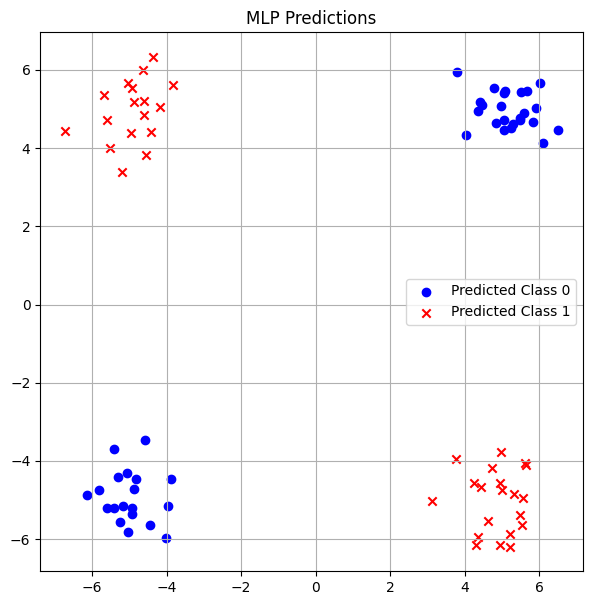

In [622]:
plt.figure(figsize=(7,7))

plt.scatter(
    X_test[preds==0][:,0],
    X_test[preds==0][:,1],
    color="blue",
    label="Predicted Class 0"
)

plt.scatter(
    X_test[preds==1][:,0],
    X_test[preds==1][:,1],
    color="red",
    marker="x",
    label="Predicted Class 1"
)

plt.legend()
plt.grid(True)
plt.title("MLP Predictions")
plt.show()

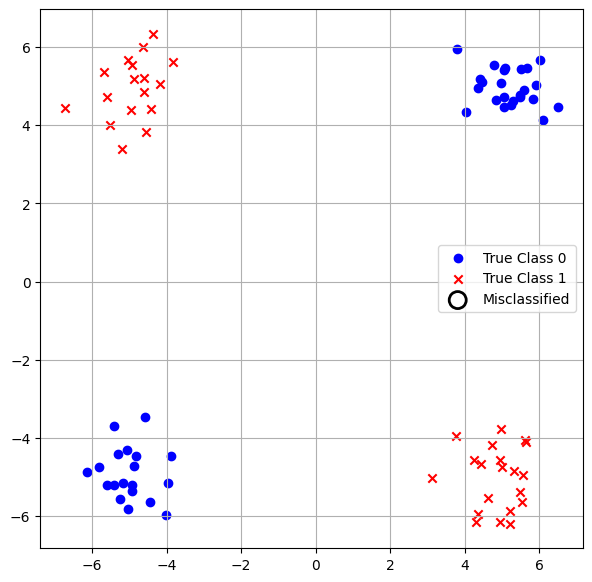

In [623]:
wrong = preds != true


plt.figure(figsize=(7,7))

plt.scatter(
    X_test[true==0][:,0],
    X_test[true==0][:,1],
    color="blue",
    label="True Class 0"
)

plt.scatter(
    X_test[true==1][:,0],
    X_test[true==1][:,1],
    color="red",
    marker="x",
    label="True Class 1"
)

plt.scatter(
    X_test[wrong][:,0],
    X_test[wrong][:,1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Misclassified"
)

plt.legend()
plt.grid(True)
plt.show()

## Decision Boundary

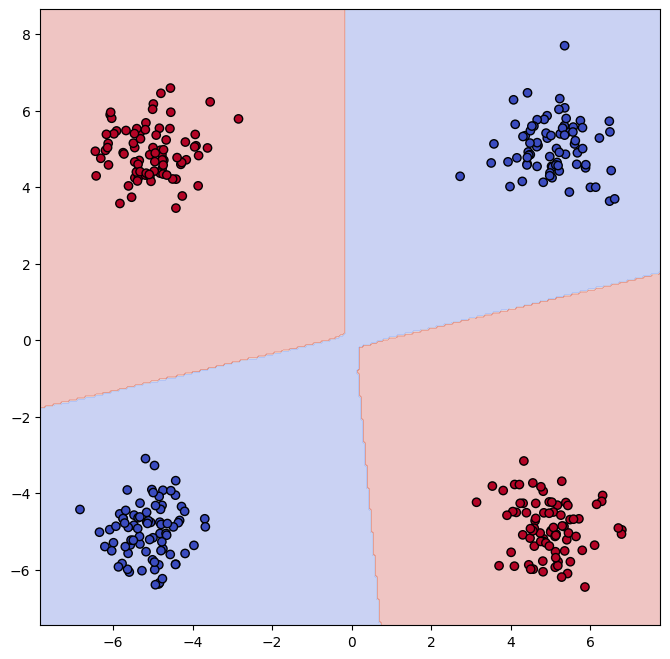

In [624]:
h = 0.05   # grid spacing

x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)
grid = np.c_[xx.ravel(), yy.ravel()]
logits = mlp(grid)

probs = sigmoid_fn(logits)
preds = np.argmax(probs, axis=1)
Z = preds.reshape(xx.shape)
plt.figure(figsize=(8,8))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap="coolwarm"
)


plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=np.argmax(y_train, axis=1),
    cmap="coolwarm",
    edgecolors="k"
)

plt.show()

**Conclusion:**

We successfully trained an MLP from scratch on an XOR dataset. In this implementation, I used **ReLU** as the hidden activation function and **one-hot encoded labels** for training.

As an exercise, try implementing the entire model yourself. For your implementation:

* Use **Sigmoid** as the hidden activation function.
* Train the network using **Cross-Entropy Loss**.
* Use **a single output neuron** for binary classification instead of two output neurons, i.e., **do not use one-hot encoding**. Instead, train the model directly with binary labels (`0` and `1`).
